## 1. 라이브러리 및 환경 설정

In [ ]:
import os
import sys
import json
import random
import pandas as pd
import numpy as np
import cv2
import shutil
import timm
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from pathlib import Path

SRC_DIR = (Path.cwd() / '../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from augmentations import build_default_transforms
from output_paths import allocate_output_paths
from reproducibility import make_generator, seed_everything, seed_worker

# /src 에서 실행하는 기준 경로 설정
DATA_DIR = (Path.cwd() / '../data').resolve()
assert DATA_DIR.exists(), f"data 폴더를 찾지 못했습니다: {DATA_DIR}"
print(f"DATA_DIR: {DATA_DIR}")

# 하이퍼파라미터 설정
CFG = {
    'IMG_SIZE': 320,
    'EPOCHS': 100,
    'LEARNING_RATE': 3e-4,
    'BATCH_SIZE': 32,
    'SEED': 42,
    'NUM_WORKERS': 16,
    'WEIGHT_DECAY': 1e-4,  # L2 regularization
    'MIXUP_ALPHA': 0.1, # 두 샘플을 섞어서 새로운 가상의 학습 데이터를 만드는 증강 기법 (lambda * ImageA + (1-lambda) * ImageB)
    'MIXUP_PROB': 0, # lambda
    'MIN_LR': 1e-6,
    'EMA_DECAY': 0.999, # 시계열에서 window size만큼 고려해 지역적 평균 구하는 방식으로 노이즈를 제거
    'EMA_USE_FOR_EVAL': True,
    'TTA_CANDIDATES': [ # TEST TIME AUGMENTATION
        ['none'],
        ['none', 'hflip'],
        ['none', 'hflip', 'crop95'],
    ],
    # video frame augmentation (for unstable videos)
    'VIDEO_AUG_ENABLE': True,
    'VIDEO_AUG_CACHE': True,
    'UNSTABLE_START_MIN_SEC': 0.5,
    'UNSTABLE_START_MAX_SEC': 1.0,
    'UNSTABLE_FRAMES_MIN': 2,
    'UNSTABLE_FRAMES_MAX': 3,
    'STABLE_END_MIN_SEC': 9.0,
    'STABLE_END_MAX_SEC': 10.0,
    'STABLE_FRAMES_PER_VIDEO': 2,
    'DISTILL_WEIGHT': 0.1 # Distill Weight for Knowledge Distillation
}

seed_everything(CFG['SEED'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

DATA_DIR: /home/vsc/LLM_TUNE/structure-stability/data
cuda


## 2. 데이터 로드 및 학습/검증 데이터 분할

In [2]:
# 1. 데이터 로드
train_df = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8-sig')
val_df = pd.read_csv(DATA_DIR / 'dev.csv', encoding='utf-8-sig')

print(f"학습 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

학습 데이터 개수: 1000
검증 데이터 개수: 100


## 3. 영상에서 Feature을 추출하는 Teacher 모델 선언

In [3]:
from transformers import VideoMAEImageProcessor, VideoMAEModel

# ────────────────────────────────────────────────────────
# 설정
# ────────────────────────────────────────────────────────
DATA_DIR     = Path('../data').resolve()
TRAIN_ROOT   = DATA_DIR / 'train'
FEATURE_DIR  = DATA_DIR / 'videomae_features'   # feature 저장 경로
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
 
MODEL_NAME   = '/home/vsc/LLM/model/videomae-base-finetuned-kinetics'
NUM_FRAMES   = 16       # VideoMAE 입력 프레임 수 (고정)
FRAME_SIZE   = 224      # VideoMAE 입력 해상도 (고정)
BATCH_SIZE   = 4        # 한 번에 처리할 비디오 수 (VRAM에 따라 조정)
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_NAME}")
print(f"Output : {FEATURE_DIR}")

# ────────────────────────────────────────────────────────
# 모델 로드
# ────────────────────────────────────────────────────────
print("\n모델 로딩 중...")
processor = VideoMAEImageProcessor.from_pretrained(MODEL_NAME) # MAE : Masked Auto Encoders
 
# VideoMAEModel: classification head 없이 feature만 추출
model = VideoMAEModel.from_pretrained(MODEL_NAME)
model.eval()
model.to(DEVICE)
print("모델 로딩 완료")

# ────────────────────────────────────────────────────────
# 비디오 → 프레임 추출 함수
# ────────────────────────────────────────────────────────
def load_video_frames(video_path: Path, num_frames: int = 16) -> list | None:
    """
    비디오에서 균등 간격으로 num_frames개의 프레임을 추출합니다.
 
    Returns:
        list of np.ndarray (H, W, 3), RGB / None if failed
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
 
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return None
 
    # 균등 간격으로 num_frames개 인덱스 선택
    # ex) frame_count=300, num_frames=16 → [0, 20, 40, ..., 300]
    indices = np.linspace(0, frame_count - 1, num_frames, dtype=int)
 
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok:
            # 실패 시 마지막 성공 프레임으로 대체
            if frames:
                frames.append(frames[-1].copy())
            else:
                cap.release()
                return None
            continue
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
 
    cap.release()
 
    if len(frames) != num_frames:
        return None
 
    return frames  # list of (H, W, 3) np.ndarray

# ────────────────────────────────────────────────────────
# feature 추출 함수
# ────────────────────────────────────────────────────────
@torch.no_grad()
def extract_features(frames: list) -> np.ndarray:
    """
    16개의 프레임 리스트 → VideoMAE CLS token feature
 
    Returns:
        np.ndarray shape (768,)  ← ViT-Base hidden dim
    """
    # processor: 리사이즈, 정규화, 텐서 변환 자동 처리
    inputs = processor(frames, return_tensors='pt')
    # inputs['pixel_values'] shape: (1, 16, 3, 224, 224)
 
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
 
    outputs = model(**inputs)
    # outputs.last_hidden_state shape: (1, num_tokens, 768)
    # num_tokens = 1(CLS) + 8*14*14 = 1569 (tube masking 기준)
 
    # CLS token (index 0) = 영상 전체를 대표하는 feature
    cls_feature = outputs.last_hidden_state[:, 0, :]  # (1, 768)
 
    return cls_feature.squeeze(0).cpu().numpy()        # (768,)

# ────────────────────────────────────────────────────────
# 전체 데이터셋에 대해 feature 추출 및 저장
# ────────────────────────────────────────────────────────
def extract_all_features(train_df: pd.DataFrame):
    """
    train_df의 모든 샘플에 대해 feature 추출 후 .npy로 저장
 
    저장 구조:
        data/videomae_features/
            000001.npy   ← shape (768,)
            000002.npy
            ...
        data/videomae_features/feature_meta.json  ← 성공/실패 기록
    """
    meta = {}
    failed = []
 
    for _, row in tqdm(train_df.iterrows(),
                       total=len(train_df),
                       desc='VideoMAE feature 추출',
                       dynamic_ncols=True,
                       ascii=True):
 
        sample_id  = str(row['id'])
        video_path = TRAIN_ROOT / sample_id / 'simulation.mp4'
        save_path  = FEATURE_DIR / f'{sample_id}.npy'
 
        # 이미 추출된 경우 스킵
        if save_path.exists():
            meta[sample_id] = 'cached'
            continue
 
        if not video_path.exists():
            meta[sample_id] = 'no_video'
            failed.append(sample_id)
            continue
 
        # 프레임 추출
        frames = load_video_frames(video_path, num_frames=NUM_FRAMES)
        if frames is None:
            meta[sample_id] = 'frame_extract_failed'
            failed.append(sample_id)
            continue
 
        # feature 추출
        try:
            feature = extract_features(frames)   # (768,)
            np.save(save_path, feature)
            meta[sample_id] = 'ok'
        except Exception as e:
            meta[sample_id] = f'error: {e}'
            failed.append(sample_id)
 
    # 메타 저장
    meta_path = FEATURE_DIR / 'feature_meta.json'
    meta_path.write_text(
        json.dumps(meta, ensure_ascii=False, indent=2)
    )
 
    print(f"\n완료: {len(train_df) - len(failed)} / {len(train_df)} 성공")
    if failed:
        print(f"실패 샘플 ({len(failed)}개): {failed[:10]}{'...' if len(failed) > 10 else ''}")
 
    return meta
 
 
# ────────────────────────────────────────────────────────
# feature 로드 유틸 (학습 코드에서 사용)
# ────────────────────────────────────────────────────────
def load_feature(sample_id: str) -> np.ndarray | None:
    """
    저장된 feature 로드
 
    Usage:
        feat = load_feature('000001')  # shape (768,)
    """
    path = FEATURE_DIR / f'{sample_id}.npy'
    if not path.exists():
        return None
    return np.load(path)
 
 
def load_all_features(sample_ids: list) -> dict:
    """
    여러 샘플의 feature를 한 번에 로드
 
    Returns:
        dict: {sample_id: np.ndarray(768,)} 또는 None(실패)
    """
    features = {}
    for sid in sample_ids:
        features[sid] = load_feature(sid)
    return features

Device : cuda
Model  : /home/vsc/LLM/model/videomae-base-finetuned-kinetics
Output : /home/vsc/LLM_TUNE/structure-stability/data/videomae_features

모델 로딩 중...


Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

VideoMAEModel LOAD REPORT from: /home/vsc/LLM/model/videomae-base-finetuned-kinetics
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
fc_norm.weight    | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 
fc_norm.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/vsc/LLM_TUNE/structure-stability/venv/venv-stability/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


모델 로딩 완료


In [4]:
train_df = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8-sig')
print(f"학습 데이터: {len(train_df)}개")

meta = extract_all_features(train_df)

# 샘플 확인
sample_id = str(train_df.iloc[0]['id'])
feat = load_feature(sample_id)
if feat is not None:
    print(f"\n샘플 feature shape : {feat.shape}")   # (768,)
    print(f"샘플 feature 통계  : mean={feat.mean():.4f}, std={feat.std():.4f}")

학습 데이터: 1000개


VideoMAE feature 추출: 100%|##########| 1000/1000 [00:00<00:00, 43876.23it/s]


완료: 1000 / 1000 성공

샘플 feature shape : (768,)
샘플 feature 통계  : mean=0.2648, std=7.8716


## 4. VideoMAE feature을 포함한 커스텀 클래스 + 데이터 로더 위한 함수 정의

In [5]:
class MultiViewDataset(Dataset):
    def __init__(self, df, root_dir, transform=None, is_test=False,
                 feature_dir=None):  # ← 추가
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        self.label_map = {'stable': 0, 'unstable': 1}
        self.feature_dir = Path(feature_dir) if feature_dir else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_id = str(row['id'])

        # 기존 이미지 로드 (동일)
        base_dir = self.root_dir
        if ('sample_dir' in self.df.columns) and pd.notna(row.get('sample_dir', np.nan)):
            base_dir = str(row['sample_dir'])

        folder_path = os.path.join(base_dir, sample_id)
        views = []
        for name in ['front', 'top']:
            img_path = os.path.join(folder_path, f'{name}.png')
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            views.append(image)

        # VideoMAE feature 로드
        feature = torch.zeros(768)  # feature 없으면 zero vector
        if self.feature_dir is not None:
            feat_path = self.feature_dir / f'{sample_id}.npy'
            if feat_path.exists():
                feature = torch.from_numpy(np.load(feat_path)).float()

        if self.is_test:
            return views, feature

        label = self.label_map[row['label']]
        return views, label, feature  # ← feature 추가 반환

In [6]:
def _extract_frame_by_sec(cap, sec, fps, frame_count):
    # 매 프레임에 해당하는 장면을 가져오는 함수
    frame_idx = int(max(0, min(frame_count - 1, round(sec * fps))))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    if not ok:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def _extract_last_frame(cap, frame_count):
    # 가장 마지막 프레임을 가져오는 함수
    last_idx = max(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, last_idx)
    ok, frame = cap.read()
    if not ok:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def _video_aug_cache_signature(cfg):
    # VIDEO_AUG에 해당하는 CFG만 가져오는 함수
    keys = [
        'SEED',
        'UNSTABLE_START_MIN_SEC',
        'UNSTABLE_START_MAX_SEC',
        'UNSTABLE_FRAMES_MIN',
        'UNSTABLE_FRAMES_MAX',
        'STABLE_END_MIN_SEC',
        'STABLE_END_MAX_SEC',
        'STABLE_FRAMES_PER_VIDEO',
    ]
    return {k: cfg.get(k) for k in keys}

def detect_collapse_start(cap, fps, frame_count, motion_threshold=0.02):
    """
    프레임 간 픽셀 변화량으로 붕괴 시작 시점 탐지
    """
    prev_frame = None
    collapse_sec = None

    # 전체 영상을 일정 간격으로 샘플링
    sample_interval = max(1, int(fps * 0.2))  # 0.2초 간격

    for frame_idx in range(0, frame_count, sample_interval):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if not ok:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(float) / 255.0

        if prev_frame is not None:
            # 프레임 간 변화량 계산
            diff = np.mean(np.abs(gray - prev_frame))
            if diff > motion_threshold:
                collapse_sec = frame_idx / fps
                break  # 첫 번째 큰 변화 시점

        prev_frame = gray

    return collapse_sec  # None이면 붕괴 미감지

def build_video_augmented_df(train_df, data_dir, cfg):
    """
    train의 simulation.mp4에서 프레임 추출 (train의 경우 )
    stable : 그냥 계속 동일한 프레임들이 나올테니, 그냥 마지막 프레임 뽑음
    unstable : 0~10초 내에 구조물이 무너지는 순간이 있을텐데, 이 변화량이 큰 순간을 포착
    """
    train_root = data_dir / 'train'
    aug_root = data_dir / 'train_video_aug'
    aug_root.mkdir(parents=True, exist_ok=True)

    cache_csv = aug_root / 'aug_df.csv'
    cache_meta = aug_root / 'cache_meta.json'
    cache_sig = _video_aug_cache_signature(cfg)

    if cfg.get('VIDEO_AUG_CACHE', True) and cache_csv.exists() and cache_meta.exists():
        try:
            meta = json.loads(cache_meta.read_text())
            if meta.get('signature') == cache_sig:
                cached_df = pd.read_csv(cache_csv)
                if not cached_df.empty:
                    cached_df['sample_dir'] = str(aug_root)
                    print(f'video aug cache hit: {len(cached_df)} samples from {cache_csv}')
                    return cached_df
        except Exception as e:
            print(f'video aug cache read failed. rebuild cache. ({e})')

    # 캐시 미스 시 기존 AUGV_* 폴더만 정리 후 재생성
    for p in aug_root.glob('AUGV_*'):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)

    rng = np.random.default_rng(cfg['SEED'])
    stable_rows = []
    unstable_rows = []
    saved_idx = 0

    def save_aug(img, label):
        nonlocal saved_idx
        aug_id = f'AUGV_{saved_idx:07d}'
        out_dir = aug_root / aug_id
        out_dir.mkdir(parents=True, exist_ok=True)
        Image.fromarray(img).save(out_dir / 'front.png')
        Image.fromarray(img).save(out_dir / 'top.png')
        row = {'id': aug_id, 'label': label, 'sample_dir': str(aug_root)}
        saved_idx += 1
        return row

    # 1) stable 증강: 영상의 마지막 프레임 1장씩 사용
    all_ids = train_df['id'].tolist()
    for sample_id in tqdm(all_ids, desc='Video aug stable(last-frame)', dynamic_ncols=True, ascii=True):
        video_path = train_root / sample_id / 'simulation.mp4'
        if not video_path.exists():
            continue

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            cap.release()
            continue

        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_count <= 0:
            cap.release()
            continue

        img = _extract_last_frame(cap, frame_count)
        cap.release()
        if img is None:
            continue

        stable_rows.append(save_aug(img, 'stable'))

    # 2) unstable 증강: 실제로 해당 구조물이 붕괴하기 시작하는 시점을 탐지
    unstable_ids = train_df.loc[train_df['label'] == 'unstable', 'id'].tolist()
    for sample_id in tqdm(unstable_ids, desc='Video aug unstable(collapse-detect)', dynamic_ncols=True, ascii=True):
        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # ← 핵심 변경: 실제 붕괴 시작 시점 탐지
        collapse_sec = detect_collapse_start(cap, fps, frame_count)

        if collapse_sec is None:
            # 탐지 실패 시 기존 방식 fallback
            low  = cfg['UNSTABLE_START_MIN_SEC']
            high = cfg['UNSTABLE_START_MAX_SEC']
        else:
            # 탐지 성공 시 붕괴 시점 기준으로 샘플링 구간 설정
            low  = max(0.0, collapse_sec - 0.3)   # 붕괴 0.3초 전
            high = min(collapse_sec + 0.5,          # 붕괴 0.5초 후
                       frame_count / fps)

        n_unstable = int(rng.integers(
            cfg['UNSTABLE_FRAMES_MIN'],
            cfg['UNSTABLE_FRAMES_MAX'] + 1
        ))
        unstable_secs = rng.uniform(low, high, size=n_unstable)

        for sec in unstable_secs:
            img = _extract_frame_by_sec(cap, sec, fps, frame_count)
            if img is None:
                continue
            unstable_rows.append(save_aug(img, 'unstable'))

        cap.release()

    stable_df = pd.DataFrame(stable_rows)
    unstable_df = pd.DataFrame(unstable_rows)

    if stable_df.empty or unstable_df.empty:
        print('video aug warning: stable/unstable 중 하나가 비어 비율 매칭 불가')
        return pd.DataFrame(columns=['id', 'label', 'sample_dir'])

    # 3) stable 개수에 맞춰 unstable 개수 정렬
    target_unstable = len(stable_df)
    if len(unstable_df) >= target_unstable:
        unstable_bal = unstable_df.sample(n=target_unstable, random_state=cfg['SEED'])
    else:
        unstable_bal = unstable_df.sample(n=target_unstable, replace=True, random_state=cfg['SEED'])

    aug_df = pd.concat([stable_df, unstable_bal], ignore_index=True)
    aug_df = aug_df.sample(frac=1.0, random_state=cfg['SEED']).reset_index(drop=True)

    # 캐시 저장
    if cfg.get('VIDEO_AUG_CACHE', True):
        aug_df.to_csv(cache_csv, index=False)
        cache_meta.write_text(json.dumps({'signature': cache_sig}, ensure_ascii=False, indent=2))
        print(f'video aug cache saved: {cache_csv}')

    print(f'video aug stable(last-frame): {len(stable_df)}')
    print(f'video aug unstable(sampled): {len(unstable_bal)}')
    return aug_df

In [7]:
train_transform, test_transform = build_default_transforms(CFG['IMG_SIZE'])

# 원본 학습 데이터(기본 1:1)
train_df_for_train = train_df.copy()
train_df_for_train['sample_dir'] = str(DATA_DIR / 'train')

# 비디오 프레임 기반 증강 데이터 생성
if CFG.get('VIDEO_AUG_ENABLE', False):
    aug_df = build_video_augmented_df(train_df, DATA_DIR, CFG)
    if len(aug_df) > 0:
        train_df_for_train = pd.concat([train_df_for_train, aug_df], ignore_index=True)
        print(f'video aug added: {len(aug_df)} samples')
    else:
        print('video aug added: 0 samples (check video availability)')

# 최종 학습 비율 확인
print('Final train class ratio:')
print(train_df_for_train['label'].value_counts())

video aug cache hit: 2000 samples from /home/vsc/LLM_TUNE/structure-stability/data/train_video_aug/aug_df.csv
video aug added: 2000 samples
Final train class ratio:
label
unstable    1500
stable      1500
Name: count, dtype: int64


In [8]:
val_df_for_eval = val_df.copy()
val_df_for_eval['sample_dir'] = str(DATA_DIR / 'dev')

FEATURE_DIR = DATA_DIR / 'videomae_features'

# 1. 학습/검증 세트 준비
train_dataset = MultiViewDataset(train_df_for_train, str(DATA_DIR / 'train'), train_transform, is_test=False, feature_dir=FEATURE_DIR)
val_dataset = MultiViewDataset(val_df_for_eval, str(DATA_DIR / 'dev'), test_transform, is_test=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'), # CPU RAM -> GPU VRAM 전송 시 더 빠른 전송 경로 사용
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'])
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'), # CPU RAM -> GPU VRAM 전송 시 더 빠른 전송 경로 사용
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 1)
)

# 2. 테스트 세트 준비
test_df = pd.read_csv(DATA_DIR / 'sample_submission.csv', encoding='utf-8-sig')
test_df_for_infer = test_df.copy()
test_df_for_infer['sample_dir'] = str(DATA_DIR / 'test')

test_dataset = MultiViewDataset(test_df_for_infer, str(DATA_DIR / 'test'), test_transform, is_test=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 2)
)

In [9]:
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

94
4
32


## 5. 모델 정의 (Multi-View )

In [10]:
from models import (
    EMAConfig,
    ModelEMA,
    MultiViewFeatureFusionConfig,
)
import dataclasses

MODEL_CONFIG = MultiViewFeatureFusionConfig()
EMA_CONFIG = EMAConfig(decay=CFG['EMA_DECAY'])
artifacts = allocate_output_paths(experiment_name='baseline', major_version='v2.0')

wandb.init(
    project="dacon-structure-stability",
    name=artifacts['version'],
    config={**CFG, **dataclasses.asdict(MODEL_CONFIG)},
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vsc/.netrc.
wandb: Currently logged in as: jungseonglian (uailab-unist_) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 6. 학습 및 검증 루프 구현

In [20]:
def mixup_multiview_batch(views, labels, alpha=0.2):
    """Apply mixup to multi-view inputs with the same permutation/lambda across all views."""
    if alpha <= 0:
        return views, labels, labels, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = labels.size(0)
    index = torch.randperm(batch_size, device=labels.device)

    mixed_views = [lam * v + (1.0 - lam) * v[index, :] for v in views]
    labels_a = labels
    labels_b = labels[index]
    return mixed_views, labels_a, labels_b, lam

from torch.cuda.amp import autocast, GradScaler

def train_one_epoch(model, loader, criterion, optimizer, device,
                    mixup_alpha=0.2, mixup_prob=0.5, ema=None,
                    distill_weight=0.1, scaler=None):  # ← distill 강도 조절
    model.train()
    train_loss = 0
   
    for views, labels, teacher_feats in tqdm(loader, desc="Training",
                                              dynamic_ncols=True, ascii=True):
        views         = [v.to(device) for v in views]
        labels        = labels.to(device).float()
        teacher_feats = teacher_feats.to(device)  # (B, 768)

        optimizer.zero_grad()

        with autocast(): # ← FP16 자동 전환 구간
            if mixup_alpha > 0 and np.random.rand() < mixup_prob:
                mixed_views, labels_a, labels_b, lam = mixup_multiview_batch(
                    views, labels, alpha=mixup_alpha
                )
                outputs, student_feats = model(mixed_views, return_feat=True)
                outputs = outputs.view(-1)
                loss_task = (lam * criterion(outputs, labels_a)
                            + (1.0 - lam) * criterion(outputs, labels_b))
            else:
                outputs, student_feats = model(views, return_feat=True)
                outputs = outputs.view(-1)
                loss_task = criterion(outputs, labels)

            # distillation loss
            valid_mask = teacher_feats.abs().sum(dim=1) > 0  # (B,)
            if valid_mask.any():
                loss_distill = F.mse_loss(
                    student_feats[valid_mask],
                    teacher_feats[valid_mask].detach()
                )
            else:
                loss_distill = torch.tensor(0.0, device=device)

            loss = loss_task + distill_weight * loss_distill # distillation weight만큼 loss 함수 정의

        scaler.scale(loss).backward()   # ← loss.backward() 대체
        scaler.step(optimizer)          # ← optimizer.step() 대체
        scaler.update()
        
        if ema is not None:
            ema.update(model)

        train_loss += loss.item()

    return train_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    val_loss  = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", dynamic_ncols=True, ascii=True):
            views, labels = batch[0], batch[1]
            views  = [v.to(device) for v in views]
            labels = labels.to(device).float()

            outputs = model(views).view(-1)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()

            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_preds,  axis=0).astype(np.float64)
    all_labels = np.concatenate(all_labels, axis=0).astype(np.float64)

    eps = 1e-15
    p = np.clip(all_probs, eps, 1 - eps)
    logloss_score = -np.mean(all_labels * np.log(p) + (1 - all_labels) * np.log(1 - p))
    acc_score     = np.mean((all_probs > 0.5) == all_labels)

    return logloss_score, acc_score

# -------------------------
# TTA helpers
# -------------------------
def _center_crop_and_resize(x, crop_ratio=0.95):
    # x: [B, C, H, W]
    b, c, h, w = x.shape
    ch, cw = int(h * crop_ratio), int(w * crop_ratio)
    y1 = (h - ch) // 2
    x1 = (w - cw) // 2
    cropped = x[:, :, y1:y1 + ch, x1:x1 + cw]
    return F.interpolate(cropped, size=(h, w), mode='bilinear', align_corners=False)


def apply_tta_to_views(views, tta_name):
    if tta_name == 'none':
        return views
    if tta_name == 'hflip':
        return [torch.flip(v, dims=[3]) for v in views]
    if tta_name == 'crop95':
        return [_center_crop_and_resize(v, crop_ratio=0.95) for v in views]
    raise ValueError(f'Unknown TTA: {tta_name}')


def predict_probs_with_tta(model, loader, device, tta_names=None, has_labels=False, desc='Inference TTA'):
    if tta_names is None:
        tta_names = ['none']

    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, dynamic_ncols=True, ascii=True):
            if has_labels:
                views, labels = batch[0], batch[1]
                labels = labels.to(device).float()
                all_labels.extend(labels.cpu().numpy())
            else:
                views = batch[0]  # ← [views] → views

            views = [v.to(device) for v in views]

            probs_sum = None
            for tta_name in tta_names:
                tta_views = apply_tta_to_views(views, tta_name)
                logits = model(tta_views).view(-1)
                probs  = torch.sigmoid(logits)
                probs_sum = probs if probs_sum is None else (probs_sum + probs)

            probs_avg = probs_sum / len(tta_names)
            all_probs.extend(probs_avg.cpu().numpy())

    all_probs = np.array(all_probs, dtype=np.float64)
    if has_labels:
        return all_probs, np.array(all_labels, dtype=np.float64)
    return all_probs


def evaluate_tta_on_dev(model, loader, device, tta_candidates):
    rows = []
    for tta_names in tta_candidates:
        probs, labels = predict_probs_with_tta(
            model, loader, device, tta_names=tta_names, has_labels=True,
            desc=f'Dev TTA {tta_names}'
        )

        eps = 1e-15
        p = np.clip(probs, eps, 1 - eps)
        logloss_score = -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))
        acc_score = np.mean((probs > 0.5) == labels)

        rows.append({
            'tta_names': tta_names,
            'n_tta': len(tta_names),
            'val_logloss': float(logloss_score),
            'val_acc': float(acc_score),
        })

    return pd.DataFrame(rows).sort_values('val_logloss', ascending=True).reset_index(drop=True)

In [12]:
class MultiViewFeatureFusionv2(nn.Module):
    def __init__(self, config: MultiViewFeatureFusionConfig):
        super().__init__()
        self.backbone = timm.create_model(
            config.backbone_name, pretrained=config.pretrained, num_classes=0
        )
        feat_dim = self.backbone.num_features

        self.fusion = nn.Sequential(
            nn.Linear(feat_dim * 2, config.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
        )
        # distillation용 projection: student feature → 768dim (VideoMAE와 맞춤)
        self.distill_proj = nn.Linear(config.hidden_dim, 768)

        self.head = nn.Linear(config.hidden_dim, config.out_dim)

    def forward(self, views, return_feat=False):
        f1 = self.backbone(views[0])
        f2 = self.backbone(views[1])
        fused = self.fusion(torch.cat([f1, f2], dim=1))  # (B, hidden_dim)
        out   = self.head(fused)                          # (B, 1)

        if return_feat:
            student_feat = self.distill_proj(fused)       # (B, 768)
            return out, student_feat

        return out

In [13]:
model = MultiViewFeatureFusionv2(MODEL_CONFIG).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=CFG['LEARNING_RATE'], weight_decay=CFG['WEIGHT_DECAY'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['EPOCHS'], eta_min=CFG['MIN_LR']
)
ema = ModelEMA(model, EMA_CONFIG)

best_logloss = float('inf')
best_epoch = -1

best_model_path = artifacts['weight_path']
submission_path = artifacts['submission_path']
print(f"Artifact version: {artifacts['version']}")

print(f"Regularization -> weight_decay={CFG['WEIGHT_DECAY']}")
print(f"MixUp -> alpha={CFG['MIXUP_ALPHA']}, prob={CFG['MIXUP_PROB']}")
print(f"Scheduler -> CosineAnnealingLR(T_max={CFG['EPOCHS']}, eta_min={CFG['MIN_LR']})")
print(f"EMA -> decay={CFG['EMA_DECAY']}, use_for_eval={CFG['EMA_USE_FOR_EVAL']}")
print(f"Distill Weight -> decay={CFG['DISTILL_WEIGHT']}")

scaler = GradScaler()

# --- Main Loop ---
for epoch in range(1, CFG['EPOCHS'] + 1):
    avg_train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        mixup_alpha=CFG['MIXUP_ALPHA'],
        mixup_prob=CFG['MIXUP_PROB'],
        ema=ema,
        distill_weight=CFG['DISTILL_WEIGHT'],
        scaler=scaler,  
    )
    eval_model = ema.ema_model if CFG['EMA_USE_FOR_EVAL'] else model
    val_logloss, val_acc = validate(eval_model, val_loader, criterion, device)

    wandb.log({
        'epoch'          : epoch,
        'train/loss'     : avg_train_loss,
        'val/logloss'    : val_logloss,
        'val/acc'        : val_acc,
        'lr'             : optimizer.param_groups[0]['lr'],
        'best_logloss'   : best_logloss,    # best 추적선
    }, step=epoch)

    if val_logloss < best_logloss:
        best_logloss = val_logloss
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.ema_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_logloss': val_logloss,
            'val_acc': val_acc,
            'cfg': CFG,
        }, best_model_path)
        print(f"  -> Best model saved: {best_model_path} (epoch={epoch}, val_logloss={val_logloss:.6f})")

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch}]")
    print(f"  - LR: {current_lr:.8f}")
    print(f"  - Train Loss: {avg_train_loss:.4f}")
    print(f"  - Val Log-Loss: {val_logloss:.6f} | Val Acc: {val_acc:.4f}")

wandb.finish()

/tmp/ipykernel_2061445/160858546.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Artifact version: v2.0.2
Regularization -> weight_decay=0.0001
MixUp -> alpha=0.1, prob=0
Scheduler -> CosineAnnealingLR(T_max=100, eta_min=1e-06)
EMA -> decay=0.999, use_for_eval=True
Distill Weight -> decay=0.1


Training:   0%|          | 0/94 [00:00<?, ?it/s]/tmp/ipykernel_2061445/2337621579.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # ← FP16 자동 전환 구간
Validation: 100%|##########| 4/4 [00:02<00:00,  1.69it/s]


  -> Best model saved: /home/vsc/LLM_TUNE/structure-stability/outputs/weights/baseline_v2.0.2.pt (epoch=1, val_logloss=0.689883)
Epoch [1]
  - LR: 0.00029993
  - Train Loss: 3.7413
  - Val Log-Loss: 0.689883 | Val Acc: 0.5400


Validation: 100%|##########| 4/4 [00:02<00:00,  1.71it/s]


...

Validation: 100%|##########| 4/4 [00:02<00:00,  1.72it/s]


Epoch [99]
  - LR: 0.00000107
  - Train Loss: 0.0308
  - Val Log-Loss: 0.383753 | Val Acc: 0.8900


Validation: 100%|##########| 4/4 [00:02<00:00,  1.73it/s]


Epoch [100]
  - LR: 0.00000100
  - Train Loss: 0.0291
  - Val Log-Loss: 0.392686 | Val Acc: 0.8900


best_logloss,██▇▆▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
lr,█████▇▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train/loss,█▅▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▅▇▇▇▇▇▇▇▇▇▇██████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
val/logloss,██▇▇▂▂▂▃▂▁▂▂▂▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▃▃▃▃▄
best_logloss,0.16382
epoch,100
lr,0.0
train/loss,0.02914
val/acc,0.89


In [14]:
# 학습 종료 후 best 가중치 로드
if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
    if CFG['EMA_USE_FOR_EVAL'] and 'ema_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['ema_state_dict'])
        print(f"Best EMA model loaded from {best_model_path} (epoch={checkpoint['epoch']}, val_logloss={checkpoint['val_logloss']:.6f})")
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Best model loaded from {best_model_path} (epoch={checkpoint['epoch']}, val_logloss={checkpoint['val_logloss']:.6f})")

Best EMA model loaded from /home/vsc/LLM_TUNE/structure-stability/outputs/weights/baseline_v2.0.2.pt (epoch=37, val_logloss=0.163816)


## 7. 검증셋 오답 확인

학습된 모델이 `dev`에서 틀린 샘플을 표와 이미지로 확인합니다.

In [17]:
if 'best_tta_names' not in globals():
    best_tta_names = ['none']

val_probs, _ = predict_probs_with_tta(
    model, val_loader, device,
    tta_names=best_tta_names,
    has_labels=True,
    desc='Validate Error Analysis (TTA)'
)

val_result = val_df.copy().reset_index(drop=True)
val_result['unstable_prob'] = val_probs
val_result['stable_prob'] = 1.0 - val_probs
val_result['pred_label'] = np.where(val_result['unstable_prob'] > 0.5, 'unstable', 'stable')

mistakes = val_result[val_result['pred_label'] != val_result['label']].copy()
mistakes['pred_confidence'] = np.where(
    mistakes['pred_label'] == 'unstable',
    mistakes['unstable_prob'],
    mistakes['stable_prob']
)
mistakes = mistakes.sort_values('pred_confidence', ascending=False).reset_index(drop=True)

print(f"사용 TTA: {best_tta_names}")
print(f"오답 개수: {len(mistakes)} / {len(val_result)}")
display(mistakes[['id', 'label', 'pred_label', 'unstable_prob', 'stable_prob', 'pred_confidence']].head(20))



Validate Error Analysis (TTA): 100%|##########| 4/4 [00:02<00:00,  1.79it/s]

사용 TTA: ['none']
오답 개수: 4 / 100


,id,label,pred_label,unstable_prob,stable_prob,pred_confidence
0,DEV_072,stable,unstable,0.998492,0.001508,0.998492
1,DEV_099,unstable,stable,0.067486,0.932514,0.932514
2,DEV_032,stable,unstable,0.910224,0.089776,0.910224
3,DEV_054,stable,unstable,0.901898,0.098102,0.901898


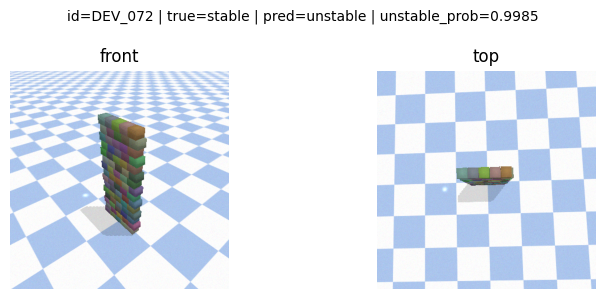

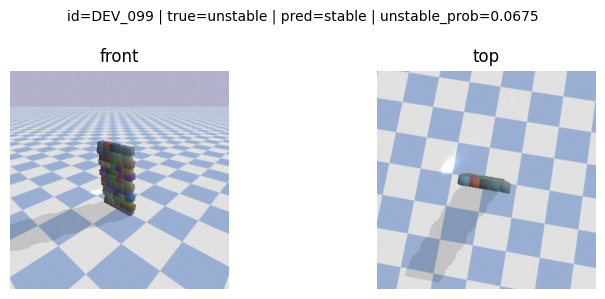

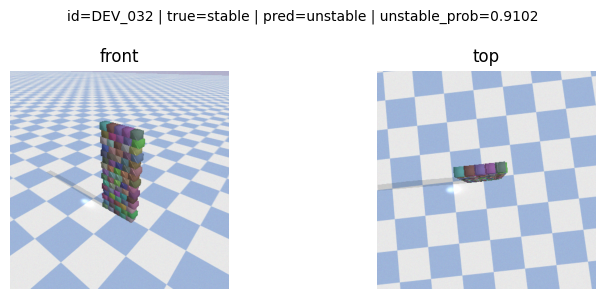

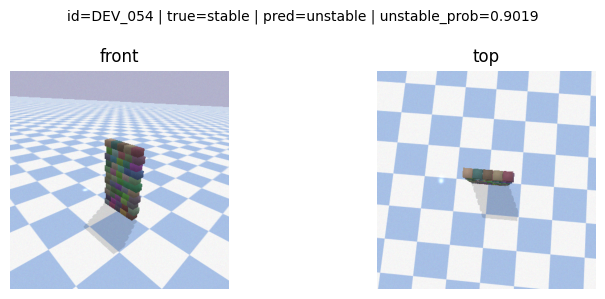

In [18]:
import matplotlib.pyplot as plt

TOP_N = 8  # 시각화할 오답 샘플 수
show_df = mistakes.head(TOP_N)

for _, row in show_df.iterrows():
    sample_id = row['id']
    front_path = DATA_DIR / 'dev' / sample_id / 'front.png'
    top_path = DATA_DIR / 'dev' / sample_id / 'top.png'

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(Image.open(front_path).convert('RGB'))
    axes[0].set_title('front')
    axes[0].axis('off')

    axes[1].imshow(Image.open(top_path).convert('RGB'))
    axes[1].set_title('top')
    axes[1].axis('off')

    fig.suptitle(
        f"id={sample_id} | true={row['label']} | pred={row['pred_label']} | unstable_prob={row['unstable_prob']:.4f}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()



## 8. 추론 및 제출 파일 생성

In [21]:
# 1) dev에서 TTA 조합 성능 비교
candidate_ttas = CFG['TTA_CANDIDATES']
tta_result_df = evaluate_tta_on_dev(model, val_loader, device, candidate_ttas)
display(tta_result_df)

best_tta_names = tta_result_df.iloc[0]['tta_names']
print(f"Best TTA on dev: {best_tta_names}")

# 2) best TTA로 test 추론
all_probs = predict_probs_with_tta(
    model, test_loader, device,
    tta_names=best_tta_names,
    has_labels=False,
    desc='Inference with TTA'
)

# 결과 저장
submission = pd.DataFrame({
    'id': test_df['id'],
    'unstable_prob': all_probs,
    'stable_prob': 1.0 - all_probs
})

submission.to_csv(submission_path, encoding='UTF-8-sig', index=False)
print(f'{submission_path} 저장 완료.')

Dev TTA ['none', 'hflip', 'crop95']: 100%|##########| 4/4 [00:04<00:00,  1.16s/it]


,tta_names,n_tta,val_logloss,val_acc
0,"[none, hflip, crop95]",3,0.136913,0.96
1,"[none, hflip]",2,0.149063,0.96
2,[none],1,0.163816,0.96


Best TTA on dev: ['none', 'hflip', 'crop95']


Inference with TTA: 100%|##########| 32/32 [00:36<00:00,  1.14s/it]

/home/vsc/LLM_TUNE/structure-stability/outputs/submissions/baseline_v2.0.2.csv 저장 완료.
